# Machine Learning: Exercise session 05

In this exercise session we explore LDA and QDA.

First, we generate and analyse synthetic datasets with different characteristics.
Visualizing the fitted models illustrates the differences between LDA and QDA.

Then, we analyse the [MNIST dataset](https://en.wikipedia.org/wiki/MNIST_database) using LDA and QDA models.

Lastly, we show for the one-dimensional case that in the the QDA classifier is a quadratic function of the predictor values.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.axes import Axes

## Problem 1 - Synthetic Data

Modified example from https://scikit-learn.org/stable/modules/lda_qda.html


### Data generation

Since LDA and QDA are generative models,
we can generate synthetic data that perfectly fits the assumptions of LDA and QDA.
Complete the function below to generate a two-class dataset, split into training and test sets of indicated sizes, that fits the assumptions of LDA and QDA.

In [2]:
def make_two_class_dataset(
    n_train=100,
    n_test=1000,
    p_0=0.5,
    mean_0=(0, 0),
    mean_1=(1, 0),
    cov_0=np.eye(2),
    cov_1=np.eye(2),
    seed=42,
):
    # Set the seed for reproducibility
    np.random.seed(seed)

    # Total number of samples
    n_samples = n_train + n_test

    # Generate y
    y = np.random.choice(2, size=n_samples, p=(p_0, 1 - p_0))

    # Create an empty feature matrix (zeros as placeholders)
    X = np.zeros((n_samples, 2))

    # Sample the features based on class labels
    n_0 = np.sum(y == 0)
    X[y == 0] = np.random.multivariate_normal(mean_0, cov_0, size=n_0)
    n_1 = np.sum(y == 1)
    X[y == 1] = np.random.multivariate_normal(mean_1, cov_1, size=n_1)

    # Split the data into training and test sets
    X_train = X[:n_train]
    X_test = X[n_train:]
    y_train = y[:n_train]
    y_test = y[n_train:]

    return X_train, X_test, y_train, y_test

To see what the generated data looks like, complete the `plot_data` function below and call it with a dataset generated by your `make_two_class_dataset` function.
We use the object-based interface of `matplotlib` here, which makes it easier to combine multiple plots into one figure.
See the [documentation](https://matplotlib.org/stable/users/explain/figure/api_interfaces.html#api-interfaces) for details.

In [3]:
def plot_data(X, y, ax: Axes):
    # Plot a scatter plot of the data points
    # Class 0 in red, class 1 in blue
    ax.scatter(X[y == 0, 0], X[y == 0, 1], c="red", marker=".")
    ax.scatter(X[y == 1, 0], X[y == 1, 1], c="blue", marker=".")

    # Set equal aspect ratio (makes circles look like circles etc.)
    ax.set_box_aspect(1)

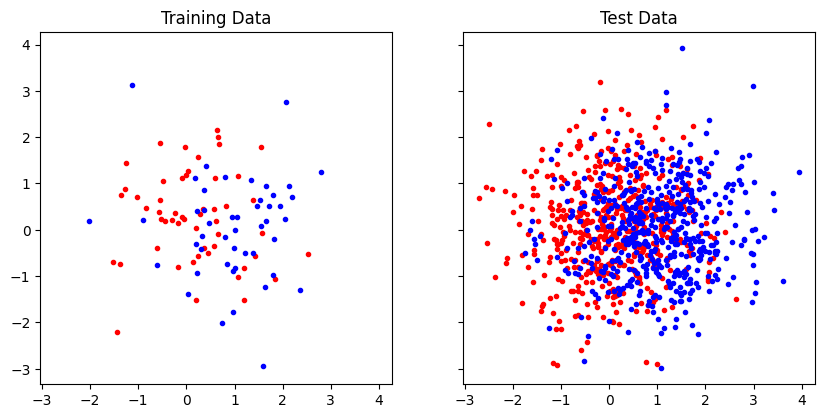

In [4]:
X_train, X_test, y_train, y_test = make_two_class_dataset()
fig, axs = plt.subplots(1, 2, figsize=(10, 5), sharex=True, sharey=True)
plot_data(X_train, y_train, axs[0])
axs[0].set_title("Training Data")
plot_data(X_test, y_test, axs[1])
axs[1].set_title("Test Data")
plt.show()

### Model fitting and evaluation

Fit an LDA and a QDA model to the training data and evaluate their accuracy on the test data.
Since we want to repeat this check for multiple different datasets, complete and call the `print_scores` function below.

In [5]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis

# Specify `store_covariance=True` to be able to analyze the estimated covariance matrices later
lda = LinearDiscriminantAnalysis(store_covariance=True)
lda.fit(X_train, y_train)

qda = QuadraticDiscriminantAnalysis(store_covariance=True)
qda.fit(X_train, y_train)

,priors,None
,reg_param,0.0
,store_covariance,True
,tol,0.0001


In [7]:
def print_scores(estimator, X_test, y_test):
    if isinstance(estimator, LinearDiscriminantAnalysis):
        model_name = "LDA"
    elif isinstance(estimator, QuadraticDiscriminantAnalysis):
        model_name = "QDA"
    else:
        model_name = "???"
    X_0 = X_test[y_test == 0]
    X_1 = X_test[y_test == 1]
    y_0 = y_test[y_test == 0]
    y_1 = y_test[y_test == 1]
    print(f"Test scores of {model_name}:")
    print(f"  on class 0: {estimator.score(X_0, y_0):.3f}")
    print(f"  on class 1: {estimator.score(X_1, y_1):.3f}")
    print(f"  overall:    {estimator.score(X_test, y_test):.3f}")
    print()

In [8]:
print_scores(lda, X_test, y_test)
print_scores(qda, X_test, y_test)

Test scores of LDA:
  on class 0: 0.736
  on class 1: 0.612
  overall:    0.674

Test scores of QDA:
  on class 0: 0.748
  on class 1: 0.594
  overall:    0.671



### Model visualization

In order to visualize the fitted models, complete the `plot_results` function below.
The functions `plot_ellipse` and `plot_decision_boundary` do what their names suggest and can be used as given below.

In [9]:
from matplotlib.patches import Ellipse
def plot_ellipse(mean, cov, color, ax: Axes):
    # Represents a mean+covariance as an ellipse
    v, w = np.linalg.eigh(cov)
    u = w[0] / np.linalg.norm(w[0])
    angle = np.arctan(u[1] / u[0])
    angle = 180 * angle / np.pi  # convert to degrees
    ell = Ellipse(
        mean,
        2 * v[0] ** 0.5,
        2 * v[1] ** 0.5,
        angle=180 + angle,
        facecolor=color,
    )
    ell.set_clip_box(ax.bbox)
    ell.set_alpha(0.4)
    ax.add_artist(ell)

In [10]:
from sklearn.inspection import DecisionBoundaryDisplay
def plot_decision_boundary(estimator, X, ax: Axes):
    DecisionBoundaryDisplay.from_estimator(
        estimator,
        X,
        response_method="predict_proba",
        plot_method="pcolormesh",
        ax=ax,
        cmap="RdBu",
        alpha=0.3,
    )
    DecisionBoundaryDisplay.from_estimator(
        estimator,
        X,
        response_method="predict_proba",
        plot_method="contour",
        ax=ax,
        alpha=1.0,
        levels=[0.5],
    )

In [12]:
def plot_results(estimator, X, y, ax: Axes):
    class_colors = ["red", "blue"]
    plot_decision_boundary(estimator, X, ax)
    y_pred = estimator.predict(X)
    for i in range(2):
        # Compute the indices of class i samples that are predicted (in)correctly
        ind_wrong = (y == i) & (y_pred != i)
        ind_right = (y == i) & (y_pred == i)

        # Make a scatter plot of the points
        # Use marker '.' for correctly classified points
        ax.scatter(X[ind_right, 0], X[ind_right, 1], c=class_colors[i], marker=".")
        # Use marker 'x' for incorrectly classified points
        ax.scatter(X[ind_wrong, 0], X[ind_wrong, 1], c=class_colors[i], marker="x")

    # Add ellipses for the estimated class means and covariances
    if isinstance(estimator, LinearDiscriminantAnalysis):
        covariances = [estimator.covariance_] * 2  # same covariance for both classes
    else:
        covariances = estimator.covariance_
    means = np.array(estimator.means_)
    plot_ellipse(means[0], covariances[0], class_colors[0], ax)
    plot_ellipse(means[1], covariances[1], class_colors[1], ax)

    # Plot the estimated class means as black points
    ax.scatter( means[:, 0], means[:, 1], c="black")

    ax.set_box_aspect(1)

Test your function by calling it with the training data you generated above.

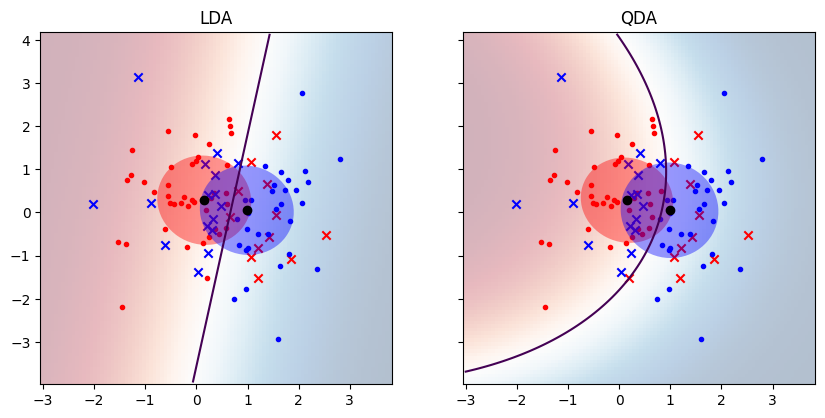

In [13]:
fig, axs = plt.subplots(1, 2, figsize=(10, 5), sharex=True, sharey=True)
plot_results(lda, X_train, y_train, axs[0])
axs[0].set_title("LDA")
plot_results(qda, X_train, y_train, axs[1])
axs[1].set_title("QDA")
plt.show()

### Combined analysis

Lastly, we put the model fitting, plotting, and score computation together in an `analyze_dataset` function that takes care of everything.

In [14]:
def analyze_dataset(X_train, X_test, y_train, y_test ):
    # Fit estimators on training data
    lda = LinearDiscriminantAnalysis(store_covariance=True)
    lda.fit(X_train, y_train)
    qda = QuadraticDiscriminantAnalysis(store_covariance=True)
    qda.fit(X_train, y_train)

    # Plot Training data, LDA results, and QDA results
    _, axs = plt.subplots(1, 3, figsize=(10, 4), sharex=True, sharey=True)
    plot_data(X_train, y_train, axs[0])
    axs[0].set_title("Data")

    plot_results(lda, X_train, y_train, axs[1])
    axs[1].set_title("LDA")

    plot_results(qda, X_train, y_train, axs[2])
    axs[2].set_title("QDA")

    plt.show()

    # Compute and print scores on test data
    print_scores(lda, X_test, y_test)
    print_scores(qda, X_test, y_test)


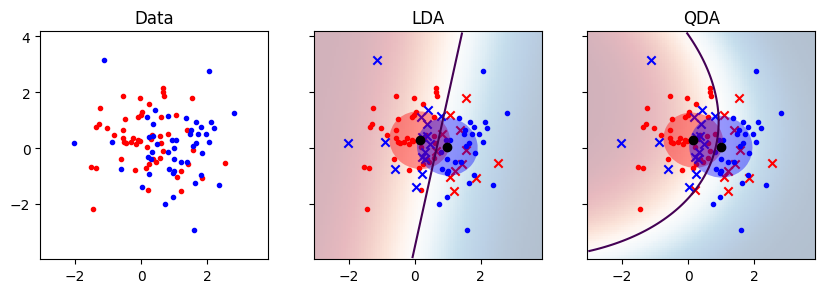

Test scores of LDA:
  on class 0: 0.736
  on class 1: 0.612
  overall:    0.674

Test scores of QDA:
  on class 0: 0.748
  on class 1: 0.594
  overall:    0.671



In [15]:
# Create dataset and analyze it
X_train, X_test, y_train, y_test = make_two_class_dataset()
analyze_dataset(X_train, X_test, y_train, y_test)

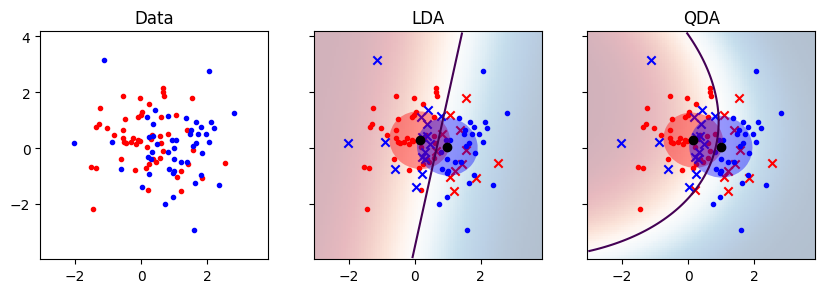

Test scores of LDA:
  on class 0: 0.736
  on class 1: 0.612
  overall:    0.674

Test scores of QDA:
  on class 0: 0.748
  on class 1: 0.594
  overall:    0.671



In [16]:
# Shorter form using argument unpacking
# Warning: not very readable, only use when you are sure about arguments/returns!
data = make_two_class_dataset()
analyze_dataset(*data)

# or even:
# analyze_dataset(*make_two_class_dataset())

Using this "pipeline", we can now now generate and visualize LDA/QDA fits for different datasets.

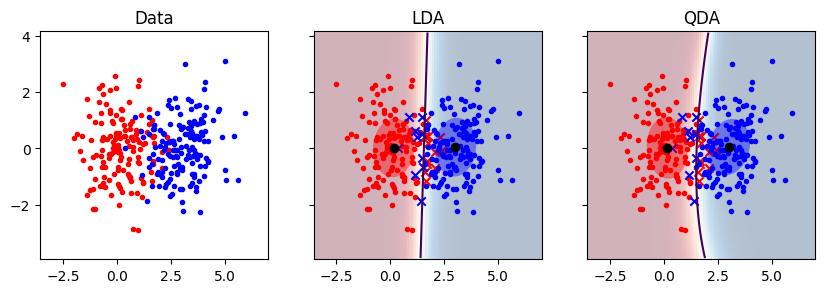

Test scores of LDA:
  on class 0: 0.942
  on class 1: 0.926
  overall:    0.934

Test scores of QDA:
  on class 0: 0.946
  on class 1: 0.926
  overall:    0.936



In [17]:
# Example: same covariance, easy to separate, plenty of data
X_train, X_test, y_train, y_test = make_two_class_dataset(
    n_train=300,
    mean_1=(3, 0),
)
analyze_dataset(X_train, X_test, y_train, y_test)

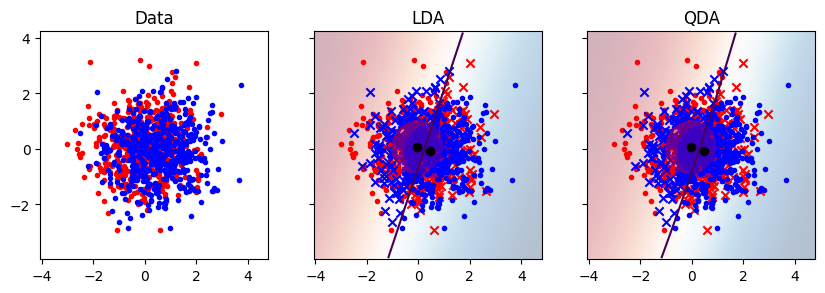

Test scores of LDA:
  on class 0: 0.589
  on class 1: 0.599
  overall:    0.594

Test scores of QDA:
  on class 0: 0.612
  on class 1: 0.578
  overall:    0.594



In [18]:
# Example: same covariance, hard to separate, plenty of data
X_train, X_test, y_train, y_test = make_two_class_dataset(
    n_train=1000,
    mean_1=(0.5, 0),
)
analyze_dataset(X_train, X_test, y_train, y_test)

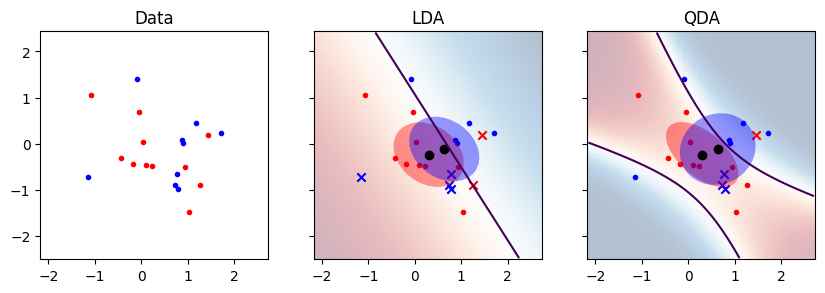

Test scores of LDA:
  on class 0: 0.661
  on class 1: 0.599
  overall:    0.630

Test scores of QDA:
  on class 0: 0.555
  on class 1: 0.553
  overall:    0.554



In [19]:
# Example: hard to separate, little data
X_train, X_test, y_train, y_test = make_two_class_dataset(
    n_train=20,
    mean_1=(1, 0),
)
analyze_dataset(X_train, X_test, y_train, y_test)

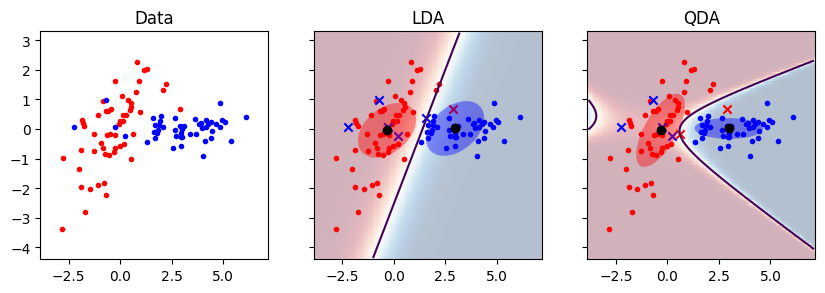

Test scores of LDA:
  on class 0: 0.924
  on class 1: 0.823
  overall:    0.873

Test scores of QDA:
  on class 0: 0.905
  on class 1: 0.903
  overall:    0.904



In [20]:
# Example: different covariances, easy to separate
cov_0 = np.array([[1.75, 1.25], [1.25, 1.75]])
cov_1 = np.array([[3, 0], [0, 0.1]])
X_train, X_test, y_train, y_test = make_two_class_dataset(
    n_train=100,
    mean_1=(3, 0),
    cov_0=cov_0,
    cov_1=cov_1,
)
analyze_dataset(X_train, X_test, y_train, y_test)

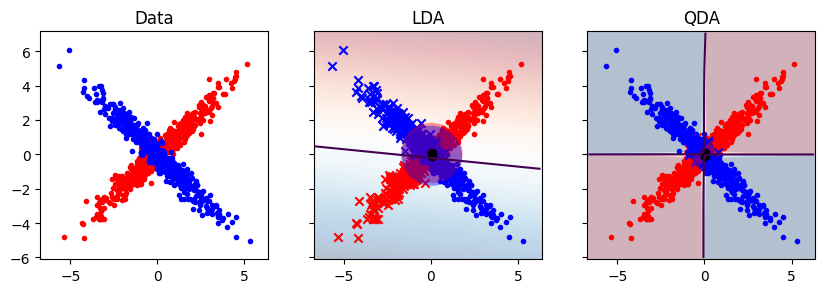

Test scores of LDA:
  on class 0: 0.541
  on class 1: 0.455
  overall:    0.497

Test scores of QDA:
  on class 0: 0.934
  on class 1: 0.919
  overall:    0.926



In [21]:
# Tricky example: different covariances, same mean
cov_0 = np.array([[3, 2.9], [2.9, 3]])
cov_1 = np.array([[3, -2.9], [-2.9, 3]])
X_train, X_test, y_train, y_test = make_two_class_dataset(
    n_train=1000,
    mean_1=(0, 0),
    cov_0=cov_0,
    cov_1=cov_1,
)
analyze_dataset(X_train, X_test, y_train, y_test)

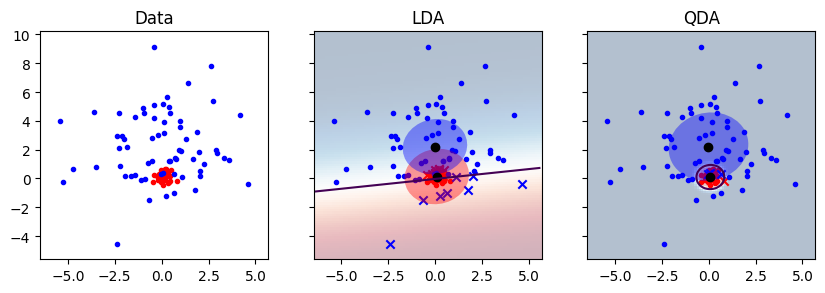

Test scores of LDA:
  on class 0: 0.441
  on class 1: 0.832
  overall:    0.709

Test scores of QDA:
  on class 0: 0.959
  on class 1: 0.956
  overall:    0.957



In [22]:
# Example: small cluster vs. large cluster
cov_0 = np.array([[0.1, 0], [0, 0.1]])
cov_1 = np.array([[5, 0], [0, 5]])
X_train, X_test, y_train, y_test = make_two_class_dataset(
    n_train=100,
    p_0=0.3,
    mean_1=(0, 2),
    cov_0=cov_0,
    cov_1=cov_1,
)
analyze_dataset(X_train, X_test, y_train, y_test)

## Problem 2 - MNIST Data

### Setup and exploration

In [23]:
# Import package/module for data
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [24]:
# Import modules for feature engineering and modelling
from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.discriminant_analysis import (
    LinearDiscriminantAnalysis,
    QuadraticDiscriminantAnalysis,
)

from sklearn.metrics import accuracy_score

Import the dataset `digits.csv`, separate the predictors and the target variable and split it into training and test set. When you perform the splitting, set `random_state=40` and `test_size=50`.

In [25]:
dat = pd.read_csv("digits.csv")
print("Original dataset shape:", dat.shape)

# Define X and Y
X = dat.drop("Y", axis = 1)
y = dat[["Y"]]

Original dataset shape: (7291, 257)


In [26]:
# Split dataset into train-test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 50, random_state = 40)

In [27]:
# Convert to numpy arrays (easier to plot etc.)
X_train = np.array(X_train)
y_train = np.array(y_train).ravel()
X_test = np.array(X_test)
y_test = np.array(y_test).ravel()

We now want to plot some of the observations of the dataset. Each row of the predictor matrix is 256 vector corresponding to a 16 x 16 image. Fill in the `??`.

In [28]:
np.random.seed(42)
row_index = np.random.randint(0, len(X_train))
np.set_printoptions(linewidth = 150)
print(X_train[row_index,:].reshape(16, 16))

[[-1.    -1.    -1.    -1.    -1.    -1.    -1.    -1.    -0.933  0.288  0.803 -0.999 -1.    -1.    -1.    -1.   ]
 [-1.    -1.    -1.    -1.    -1.    -1.    -1.    -0.954  0.457  0.959 -0.527 -1.    -1.    -1.    -1.    -1.   ]
 [-1.    -1.    -1.    -1.    -1.    -1.    -0.973  0.237  0.986 -0.315 -1.    -1.    -1.    -1.    -1.    -1.   ]
 [-1.    -1.    -1.    -1.    -1.    -0.99   0.143  1.     0.265 -1.    -1.    -1.    -1.    -1.    -1.    -1.   ]
 [-1.    -1.    -1.    -1.    -1.     0.042  1.     0.493 -0.964 -1.    -1.    -1.    -1.    -1.    -1.    -1.   ]
 [-1.    -1.    -1.    -1.     0.067  0.994  0.455 -0.945 -1.    -1.    -1.    -1.    -1.    -1.    -1.    -1.   ]
 [-1.    -1.    -1.    -0.164  0.986  0.658 -0.908 -1.    -1.    -1.    -1.    -1.    -1.    -1.    -1.    -1.   ]
 [-1.    -1.    -0.561  0.949  0.778 -0.724 -1.    -1.    -1.    -1.    -1.    -1.    -1.    -1.    -1.    -1.   ]
 [-1.    -0.978  0.571  0.991 -0.456 -1.    -1.    -1.    -1.    -1.    -1.    -

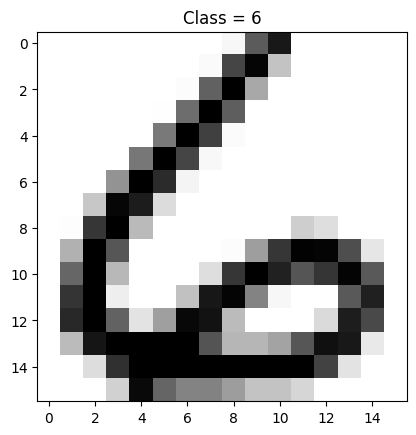

In [29]:
np.random.seed(42)
row_index = np.random.randint(0, len(X_train))
image_data = X_train[row_index,:].reshape((16, 16))
plt.imshow(image_data, cmap="binary")
plt.title(f"Class = {y_train[row_index]}")
plt.show()

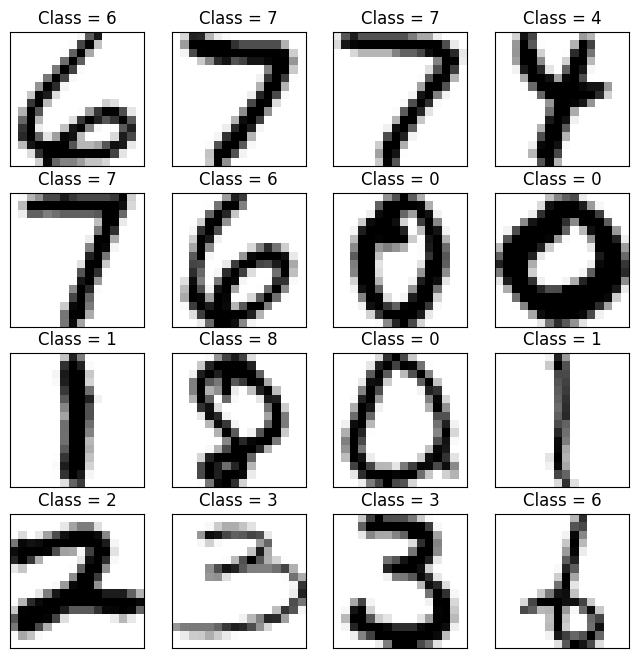

In [30]:
# Plot some figures
n_rows = 4
n_cols = 4
fig, ax = plt.subplots(n_rows, n_cols, figsize=(8, 8))
np.random.seed(42)
for i in range(n_rows):
    for j in range(n_cols):
        row_index = np.random.randint(0, len(X_train))
        image_data = X_train[row_index,:].reshape((16, 16))
        ax[i, j].imshow(image_data, cmap="binary")
        ax[i, j].set_title(f"Class = {y_train[row_index]}")
        ax[i, j].set_xticks([])
        ax[i, j].set_yticks([])
plt.show()

### LDA

We now try to fit an LDA model.
Mathematically, LDA is invariant under linear transformations (rescaling) of the predictors.
However, for numerical stability or when using regularization, it is a good idea to rescale the data anyways.
Create a `Pipeline` that first standardizes the data and then fits an LDA model.



Explain better the impact of the standardscaler() and the impact on the images?

In [31]:
# Define pipeline
lda = LinearDiscriminantAnalysis(shrinkage = 'auto', solver = 'lsqr')
scaler_lda = StandardScaler()
pipe_lda = Pipeline([
    ("scaler", scaler_lda),
    ("lda", lda),
])

# Fit pipeline
pipe_lda.fit(X_train, y_train)

# Predict on training data
y_train_pred = pipe_lda.predict(X_train)
acc = accuracy_score(y_train, y_train_pred)
print("LDA --- Accuracy on training data:", np.round(acc, 3))

# Predict on test data
y_test_pred = pipe_lda.predict(X_test)
acc = accuracy_score(y_test, y_test_pred)
print("LDA --- Accuracy on test data:", np.round(acc, 3))


LDA --- Accuracy on training data: 0.932
LDA --- Accuracy on test data: 0.92


Since LDA estimates the class-conditional means, it can be useful to try to understand qualitatively how these look like. What do these mean correspond to?

In [32]:
lda.means_

array([[-0.04168416, -0.09387023, -0.13777471, ..., -0.17129778,
        -0.13017675, -0.08085524],
       [-0.06854447, -0.12457936, -0.19979238, ..., -0.18448782,
        -0.13057813, -0.08085524],
       [ 0.06181818,  0.12623891,  0.19378968, ...,  1.02678123,
         0.97100016,  0.69510531],
       ...,
       [ 0.42274952,  0.67764337,  0.77152005, ..., -0.18653457,
        -0.13057813, -0.08085524],
       [-0.03916651, -0.02052527,  0.05084621, ..., -0.16584081,
        -0.13055483, -0.08085524],
       [-0.06656758, -0.11495025, -0.18175488, ..., -0.1719042 ,
        -0.12388798, -0.08085524]], shape=(10, 256))

In [33]:
lda.means_.shape # type: ignore

(10, 256)

Since we know that the data represents images of digits, we can try to plot the means as images.

In [34]:
def plot_means(means, method_name):
    """
    ndarray string -> plot
    plot the mean vectors estimated by LDA/QDA
    """
    plt.figure(figsize=(10, 5))
    for i in range(10):
        l1_plot = plt.subplot(2, 5, i + 1)
        l1_plot.imshow(means[i,:].reshape(16, 16), cmap="binary")
        l1_plot.set_xticks(())
        l1_plot.set_yticks(())
        l1_plot.set_xlabel(f"Class {i}")
    plt.suptitle("Means estimated by " + method_name)
    plt.show()

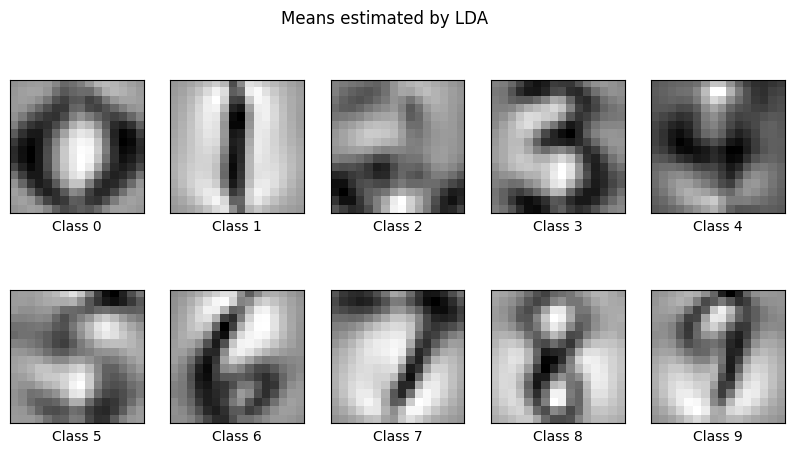

In [35]:
plot_means(lda.means_, "LDA")

Plotting the means, we see that they roughly look like the digits they are supposed to represent.
However, they are a bit distorted. Why is that and how could we fix that?

*Hint: Remember that we fitted an entire pipeline, not just the LDA estimator*

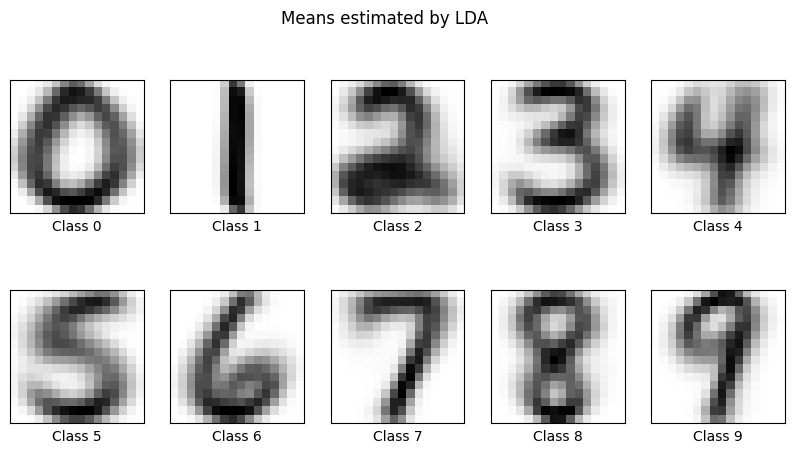

In [36]:
# We need to invert the scaler transformation:
# X_scaled = (X - mean(X)) / sd(X)   ==>   X = X_scaled * sd(X) + mean(X)
# Or just use the inverse_transform method of the scaler object:

lda_means = scaler_lda.inverse_transform(lda.means_)

plot_means(lda_means, "LDA")

### QDA

Repeat the same analysis as above but now using QDA.
If you create a `QuadraticDiscriminantAnalysis` object without any arguments, you will see that it does not work properly.
Why is that?
Fix the problem by setting the argument `reg_param` to a small value (e.g. 0.01).

In [37]:
# QDA
# Define pipeline
qda = QuadraticDiscriminantAnalysis(reg_param=0.01)
scaler_qda = StandardScaler()
pipe_qda = Pipeline([
    ("scaler", scaler_qda),
    ("qda", qda),
])

# Fit pipeline
pipe_qda.fit(X_train, y_train)

,steps,"[('scaler', ...), ('qda', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,priors,None
,reg_param,0.01
,store_covariance,False
,tol,0.0001


In [38]:
# Predict on training data
y_train_pred = pipe_qda.predict(X_train)
acc = accuracy_score(y_train, y_train_pred)
print("QDA --- Accuracy on training data:", np.round(acc, 3))

# Predict on test data
y_test_pred = pipe_qda.predict(X_test)
acc = accuracy_score(y_test, y_test_pred)
print("QDA --- Accuracy on test data:", np.round(acc, 3))

QDA --- Accuracy on training data: 0.988
QDA --- Accuracy on test data: 0.92


As we did for LDA, plot the means estimated by QDA. Call the function you created by passing as an argument the matrix with the estimated means.

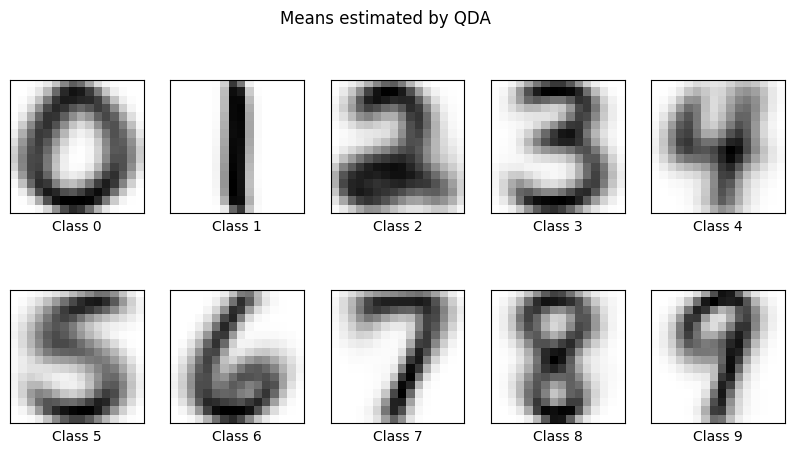

In [39]:
# Plot means
qda_means = scaler_qda.inverse_transform(qda.means_)
plot_means(qda_means, "QDA")

Do these look different from the means estimated by LDA? Why (not)?
Verify your answer using `numpy`.

In [40]:
np.all(lda_means == qda_means)

np.True_

_Bonus_: What do the estimated covariance matrices look like, what do they represent? Can you think of a way to visualize them?

## Problem 3

This problem is about quadratic discriminant analysis (QDA).
The observations within each class are modeled by a normal distribution with a class specific mean vector and a class specific covariance matrix. We consider the simple case where $p = 1$, (i.e., there is only one feature) and that we have $q = 2$ classes. Thus, for $j=0,1$, the conditional distribution $X\mid Y=j$ of the $j$-th class is one-dimensional normal $N(\mu_j, \sigma^2_j)$. 
Show that in this case, the QDA classifier is not linear in $x$, but _quadratic_,
i.e., that the decision boundary is given as the solution of a quadratic equation in $x$.

### Solution

We have that $X\mid Y= 0 \sim N(\mu_0, \sigma_0^2)$ and $X\mid Y= 1 \sim N(\mu_1, \sigma_1^2)$, with
\begin{align*}
  f_{X\mid Y = j} = \dfrac{1}{\sqrt{2\pi \sigma_j^2}}\exp\left\{-\dfrac{1}{2}\dfrac{(x - \mu_j)^2}{\sigma_j^2}\right\}, \quad j = 0, 1.
\end{align*}
Let $\mathbb{P}(Y = 1)=\pi_1$ and $\mathbb{P}(Y = 0)=\pi_0=1-\pi_1$.

The discriminant functions are
\begin{align*}
  \begin{split}
  LP_1(x) = &\ \log f_{X\mid Y = 1} + \log \mathbb{P}(Y = 1)\\
  = &\ -\dfrac{1}{2}\log(2\pi) -\dfrac{1}{2}\log(\sigma_1^2) - \dfrac{1}{2}\dfrac{(x - \mu_1)^2}{\sigma_1^2} + \log(\pi_1),  \\
  LP_0(x) = &\ \log f_{X\mid Y = 0} + \log \mathbb P(Y = 0)\\
  = &\ -\dfrac{1}{2}\log(2\pi) -\dfrac{1}{2}\log(\sigma_0^2) - \dfrac{1}{2}\dfrac{(x - \mu_0)^2}{\sigma_0^2} + \log(1 - \pi_1).
  \end{split}
\end{align*}
  
The decision boundary is the solution to 
\begin{align*}
  \delta(x) =&\ LP_1(x) - LP_0(x)=0\\
  \delta(x) = &\ \dfrac{1}{2}\left[\dfrac{(x - \mu_0)^2}{\sigma_0^2} - \dfrac{(x - \mu_1)^2}{\sigma_1^2}\right]
   +\dfrac{1}{2}\log(\sigma_0^2/\sigma_1^2) + \log(\pi_1/(1 - \pi_1)) \\
  = &\ \dfrac{1}{2\sigma_0^2\sigma_1^2}\left[\left(\sigma_1^2 - \sigma_0^2\right) x^2 + 2\left(\mu_1\sigma_0^2 - \mu_0\sigma_1^2\right)x + \sigma_1^2\mu_0^2 - \sigma_0^2\mu_1^2\right] \\
  &\ + \dfrac{1}{2}\log(\sigma_0^2/\sigma_1^2) + \log(\pi_1/(1 - \pi_1))\\
 = &\ \left(\dfrac{\sigma_1^2 - \sigma_0^2}{2\sigma_0^2\sigma_1^2}\right) x^2 
 +\left(\dfrac{\mu_1\sigma_0^2 - \mu_0\sigma_1^2}{\sigma_0^2\sigma_1^2}\right) x + \mathrm{constant}=0.
\end{align*}
  
We see that the classifier is _quadratic_ in $x$. This is because $\sigma_1^2$ and $\sigma_0^2$ are not assumed to be equal in QDA. Notice that if we let $\sigma_1^2 = \sigma_0^2$, the quadratic term disappears, and we are left with a LDA linear classifier.